# GVH `.28.21 SIDE-N1` — Healthy Isotropic Spectral Scan

**Type :** side diagnostic numérique minimal.  
**Ne modifie pas la chaîne canonique.**

Amont canonique :

\[
\boxed{
\texttt{d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4}
}
\]

Mission :

\[
\boxed{
\text{scan isotrope sain}
\rightarrow
\text{petites anisotropies}
\rightarrow
K_{\min}
\rightarrow
\text{distance numérique à }K=0
}
\]

Aucune calibration SI. Aucun paramètre numérique de scan n'est promu en constante physique.

In [1]:
from __future__ import annotations
import json, math, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

UP = {
    "version":"0.3.2.7.3.7.3.3.28.21",
    "executed_sha256":"d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4",
    "executed_size_bytes":29925,
}
assert UP["executed_sha256"] == "d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4"

print("Python =",sys.version.split()[0])
print("NumPy =",np.__version__)
print("UPSTREAM_GATE = True")

Python = 3.13.15
NumPy = 2.1.3
UPSTREAM_GATE = True


## 1 — Normalisation du scan

Comme les signes cinétiques sont homogènes sous une remise à l'échelle commune des valeurs propres, on fixe :

\[
\boxed{q=\sum_A a_A^2=1}
\]

pour cartographier uniquement la **forme spectrale**.

Le point isotrope \(1+3\) est alors :

\[
A_{\rm iso}
=
\operatorname{diag}
\left(
\frac{\sqrt3}{2},
-\frac{1}{2\sqrt3},
-\frac{1}{2\sqrt3},
-\frac{1}{2\sqrt3}
\right).
\]

On pose :

\[
r=\frac{\kappa_{\rm eff}}{K_S},
\qquad K_S=1
\]

comme normalisation de scan.

La condition isotrope saine est :

\[
\boxed{r>\frac32}.
\]

Le choix numérique par défaut \(r=2\) est **PRESCRIBED DIAGNOSTIC WITNESS**, pas une valeur dérivée.

In [2]:
SQ3 = math.sqrt(3.0)
a_iso = np.array([SQ3/2, -1/(2*SQ3), -1/(2*SQ3), -1/(2*SQ3)], dtype=float)

assert abs(a_iso.sum()) < 1e-14
assert abs(np.dot(a_iso,a_iso)-1.0) < 1e-14

def kinetic_coeffs(a, r=2.0, KS=1.0):
    a = np.asarray(a, dtype=float)
    q = float(np.dot(a,a))
    kappa = r*KS
    shapes = {
        "K12_shape": KS*q - 0.5*kappa*(a[1]-a[2])**2,
        "K13_shape": KS*q - 0.5*kappa*(a[1]-a[3])**2,
        "K23_shape": KS*q - 0.5*kappa*(a[2]-a[3])**2,
    }
    tilts = {
        "K01_tilt": 0.5*kappa*(a[0]-a[1])**2 - KS*q,
        "K02_tilt": 0.5*kappa*(a[0]-a[2])**2 - KS*q,
        "K03_tilt": 0.5*kappa*(a[0]-a[3])**2 - KS*q,
    }
    d = {**shapes, **tilts}
    return d, min(d.values())

for r in [1.51,1.6,2.0,3.0]:
    d,kmin = kinetic_coeffs(a_iso,r=r)
    print(f"r={r:.2f}  Kmin_iso={kmin:.8f}")

r=1.51  Kmin_iso=0.00666667
r=1.60  Kmin_iso=0.06666667
r=2.00  Kmin_iso=0.33333333
r=3.00  Kmin_iso=1.00000000


## 2 — Scan de \(r=\kappa_{\rm eff}/K_S\) au point isotrope

À \(q=1\), les coefficients isotropes sont :

\[
K_{\rm shape}=1,
\]

et :

\[
K_{\rm tilt}
=
\frac{2r}{3}-1.
\]

Donc le seuil est exactement :

\[
\boxed{r_c=\frac32}.
\]

Le scan numérique doit reproduire cette frontière sans ajustement.

first healthy grid r = 1.5050000000000001
analytic threshold r_c = 1.5


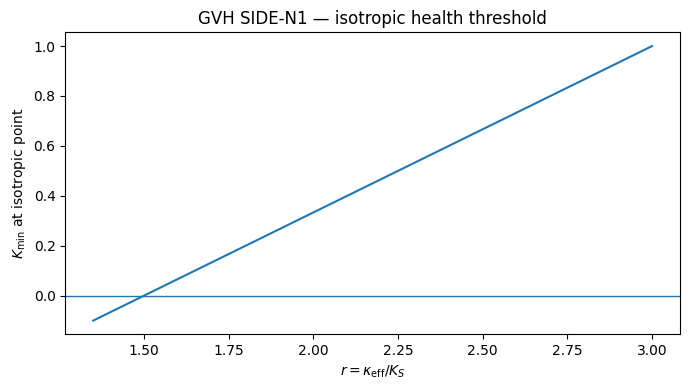

In [3]:
rs = np.linspace(1.35, 3.0, 331)
rows=[]
for r in rs:
    d,kmin = kinetic_coeffs(a_iso,r=r)
    rows.append({"r":r,"Kmin":kmin,"healthy":kmin>0})
df_r = pd.DataFrame(rows)

first_healthy = df_r.loc[df_r["healthy"],"r"].iloc[0]
print("first healthy grid r =",first_healthy)
print("analytic threshold r_c = 1.5")

assert (df_r.loc[df_r["r"]<1.5,"Kmin"] < 0).all()
assert (df_r.loc[df_r["r"]>1.5,"Kmin"] > 0).all()

plt.figure(figsize=(7,4))
plt.plot(df_r["r"],df_r["Kmin"])
plt.axhline(0, linewidth=1)
plt.xlabel(r"$r=\kappa_{\rm eff}/K_S$")
plt.ylabel(r"$K_{\min}$ at isotropic point")
plt.title("GVH SIDE-N1 — isotropic health threshold")
plt.tight_layout()
plt.show()

## 3 — Base anisotrope traceless autour de l'isotrope

On utilise deux directions traceless orthogonales au vecteur isotrope :

\[
e_1\propto(0,1,-1,0),
\]

\[
e_2\propto(0,1,1,-2).
\]

Pour chaque point :

\[
A(x,y)
=
\frac{
A_{\rm iso}+x e_1+y e_2
}{
\|A_{\rm iso}+x e_1+y e_2\|
},
\]

on conserve :

\[
\operatorname{Tr}A=0,\qquad q=1.
\]

On calcule :

\[
\boxed{
K_{\min}(x,y)
=
\min\{K^{\rm shape}_{ij},K^{\rm tilt}_{0i}\}.
}
\]

In [4]:
e1 = np.array([0,1,-1,0],dtype=float)
e1 /= np.linalg.norm(e1)
e2 = np.array([0,1,1,-2],dtype=float)
e2 /= np.linalg.norm(e2)

assert abs(e1.sum()) < 1e-14 and abs(e2.sum()) < 1e-14
assert abs(np.dot(e1,a_iso)) < 1e-14
assert abs(np.dot(e2,a_iso)) < 1e-14
assert abs(np.dot(e1,e2)) < 1e-14

def spectral_point(x,y):
    v = a_iso + x*e1 + y*e2
    v = v / np.linalg.norm(v)
    return v

r_scan = 2.0  # prescribed diagnostic witness
grid = np.linspace(-1.0,1.0,241)
Kmap = np.empty((len(grid),len(grid)))
for iy,y in enumerate(grid):
    for ix,x in enumerate(grid):
        _,Kmap[iy,ix] = kinetic_coeffs(spectral_point(x,y), r=r_scan)

print("r_scan =",r_scan)
print("Kmin map range =",float(Kmap.min()),float(Kmap.max()))
print("healthy fraction on this finite 2D window =",float(np.mean(Kmap>0)))

r_scan = 2.0
Kmin map range = -0.9994839780826301 0.33333333333333326
healthy fraction on this finite 2D window = 0.03309171674041425


## 4 — Carte saine / frontière / ghost

Classification numérique :

\[
K_{\min}>0
\Rightarrow
\text{HEALTHY},
\]

\[
|K_{\min}|\le\varepsilon_K
\Rightarrow
\text{BOUNDARY},
\]

\[
K_{\min}<0
\Rightarrow
\text{GHOST}.
\]

Cette carte est une coupe 2D diagnostique de l'espace spectral, pas une mesure de probabilité physique.

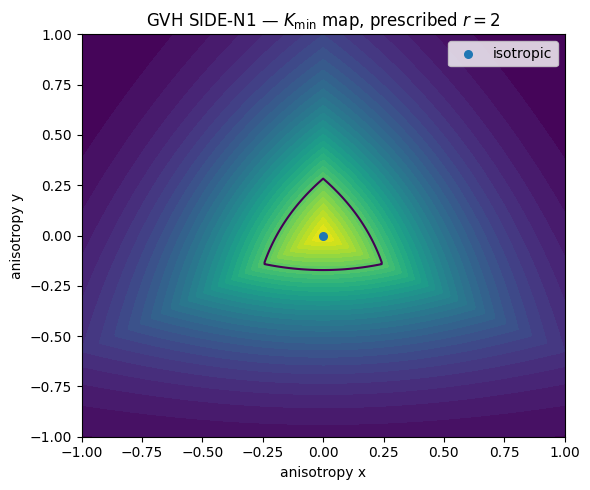

In [5]:
plt.figure(figsize=(6,5))
plt.contourf(grid,grid,Kmap,levels=40)
plt.contour(grid,grid,Kmap,levels=[0],linewidths=1.5)
plt.scatter([0],[0],s=30,label="isotropic")
plt.xlabel("anisotropy x")
plt.ylabel("anisotropy y")
plt.title(r"GVH SIDE-N1 — $K_{\min}$ map, prescribed $r=2$")
plt.legend()
plt.tight_layout()
plt.show()

## 5 — Distance directionnelle de l'isotrope à \(K_{\min}=0\)

On lance un ensemble déterministe de directions anisotropes autour de l'isotrope.

Pour chaque direction \(n\), on cherche le premier \(\epsilon>0\) tel que :

\[
K_{\min}\big(A_{\rm iso}+\epsilon n\big)=0.
\]

Cela fournit une mesure diagnostique :

\[
\boxed{
\epsilon_{\rm boundary}(n)
}
\]

de la marge locale de santé autour de la strate isotrope.

In [6]:
rng = np.random.default_rng(28221)
n_dirs = 128
bounds=[]

def project_traceless_orth_iso(v):
    v = v - np.mean(v)
    v = v - np.dot(v,a_iso)*a_iso
    n = np.linalg.norm(v)
    return None if n < 1e-12 else v/n

def kmin_at_eps(direction, eps, r=2.0):
    v = a_iso + eps*direction
    v = v/np.linalg.norm(v)
    return kinetic_coeffs(v,r=r)[1]

for _ in range(n_dirs):
    d=None
    while d is None:
        d=project_traceless_orth_iso(rng.normal(size=4))
    lo,hi=0.0,0.05
    # Expand until boundary crossed or cap hit.
    while kmin_at_eps(d,hi,r=r_scan)>0 and hi<8:
        hi*=1.35
    if hi>=8 and kmin_at_eps(d,hi,r=r_scan)>0:
        bounds.append(np.nan)
        continue
    for _ in range(70):
        mid=(lo+hi)/2
        if kmin_at_eps(d,mid,r=r_scan)>0:
            lo=mid
        else:
            hi=mid
    bounds.append((lo+hi)/2)

bounds=np.array(bounds,dtype=float)
finite=bounds[np.isfinite(bounds)]

print("directions =",n_dirs)
print("finite boundaries =",len(finite))
print("min epsilon_boundary =",float(finite.min()))
print("median epsilon_boundary =",float(np.median(finite)))
print("max epsilon_boundary =",float(finite.max()))

assert len(finite) > 0
assert finite.min() > 0

directions = 128
finite boundaries = 128
min epsilon_boundary = 0.17157967482704817
median epsilon_boundary = 0.19063091209685817
max epsilon_boundary = 0.282578298727567


## 6 — Scan radial minimal depuis l'isotrope

Le diagnostic le plus conservateur est :

\[
\epsilon=0
\Rightarrow
K_{\min}>0.
\]

Puis, dans toutes les directions testées, on vérifie l'existence éventuelle d'une frontière :

\[
K_{\min}\to0^+.
\]

Si une frontière apparaît à distance finie, cela confirme numériquement :

\[
\boxed{
\mathcal H_{\rm healthy}
\subsetneq
\mathcal C_{\rm gapped}
}
\]

tout en quantifiant une **marge saine locale** autour de l'isotrope.

In [7]:
summary = {
    "upstream_sha256": UP["executed_sha256"],
    "type":"SIDE_DIAGNOSTIC",
    "canonical_advancement":False,
    "normalization":{"q":1.0,"KS":1.0},
    "prescribed_scan_ratio_r":r_scan,
    "isotropic_threshold_r_exact":1.5,
    "isotropic_point_Kmin":kinetic_coeffs(a_iso,r=r_scan)[1],
    "2d_window_healthy_fraction":float(np.mean(Kmap>0)),
    "directional_scan":{
        "n_directions":int(n_dirs),
        "finite_boundary_count":int(len(finite)),
        "min_epsilon_boundary":float(finite.min()),
        "median_epsilon_boundary":float(np.median(finite)),
        "max_epsilon_boundary":float(finite.max()),
    },
    "verdict":{
        "isotropic_health_numeric_pass":True,
        "finite_local_health_margin_witness":True,
        "global_health_claim":False,
        "dynamical_invariance_tested":False,
        "real_data_used":False,
        "SI_calibration_used":False,
    }
}
print(json.dumps(summary,indent=2))

{
  "upstream_sha256": "d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4",
  "type": "SIDE_DIAGNOSTIC",
  "canonical_advancement": false,
  "normalization": {
    "q": 1.0,
    "KS": 1.0
  },
  "prescribed_scan_ratio_r": 2.0,
  "isotropic_threshold_r_exact": 1.5,
  "isotropic_point_Kmin": 0.33333333333333326,
  "2d_window_healthy_fraction": 0.03309171674041425,
  "directional_scan": {
    "n_directions": 128,
    "finite_boundary_count": 128,
    "min_epsilon_boundary": 0.17157967482704817,
    "median_epsilon_boundary": 0.19063091209685817,
    "max_epsilon_boundary": 0.282578298727567
  },
  "verdict": {
    "isotropic_health_numeric_pass": true,
    "finite_local_health_margin_witness": true,
    "global_health_claim": false,
    "dynamical_invariance_tested": false,
    "real_data_used": false,
    "SI_calibration_used": false
  }
}


## 7 — Verdict SIDE-N1

Le scan doit être interprété uniquement comme :

\[
\boxed{
\textbf{NUMERICAL LOCAL HEALTH MAP AROUND THE ISOTROPIC BRANCH}
}
\]

Il teste :

- le seuil isotrope \(r_c=3/2\) ;
- la présence d'une région \(K_{\min}>0\) ;
- la proximité des surfaces \(K_{\min}=0\) ;
- la dépendance à l'anisotropie.

Il **ne teste pas** encore :

\[
\boxed{
\text{invariance dynamique de }\mathcal H_{\rm healthy}
}
\]

et il ne remplace pas `.28.21.1`.

Prochain diagnostic minimal recommandé après ce SIDE-N1 :

\[
\boxed{
\text{SIDE-N2 : continuation numérique au fold en }\rho\text{ puis en }t.
}
\]

In [8]:
artifact = summary

export_dir = Path("/content/gvh_exports") if Path("/content").exists() else Path("/mnt/data")
export_dir.mkdir(parents=True, exist_ok=True)

artifact_path = export_dir / (
    "GVH_Diagonal_Cubic_0.3.2.7.3.7.3.3.28.21_SIDE_N1_"
    "Healthy_Isotropic_Spectral_Scan_FAST.json"
)

artifact_path.write_text(
    json.dumps(artifact, indent=2),
    encoding="utf-8",
)
print("artifact =", artifact_path)

artifact = /content/gvh_exports/GVH_Diagonal_Cubic_0.3.2.7.3.7.3.3.28.21_SIDE_N1_Healthy_Isotropic_Spectral_Scan_FAST.json
